In [1]:
from warnings import filterwarnings
import random

import torch.cuda as cuda

import sys
sys.path.append('../')

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
adata = sc.read_h5ad('../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad')
adata

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [3]:
node_ids = np.load('../output/pbmc_benchmark_data/Node_Ids.npy')
cell_emb = np.load('../output/pbmc_benchmark_data/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'cell_emb'
    layers: 'counts'

In [4]:
pred = np.load('../output/pbmc_benchmark_data/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [5]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


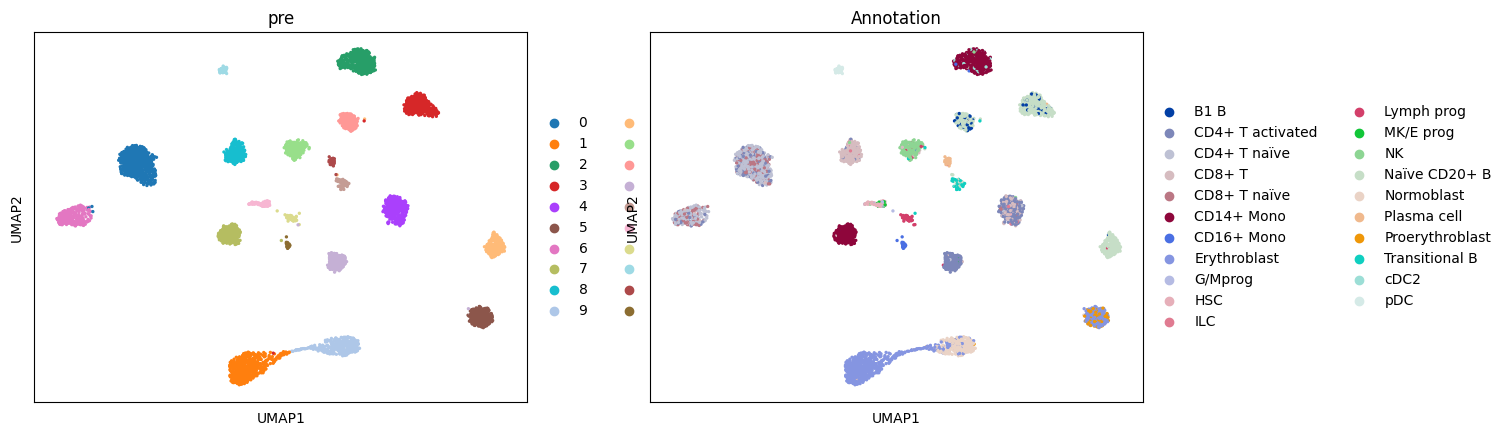

In [6]:
sc.pl.umap(adata, color=['pre', 'Annotation'], show=True)

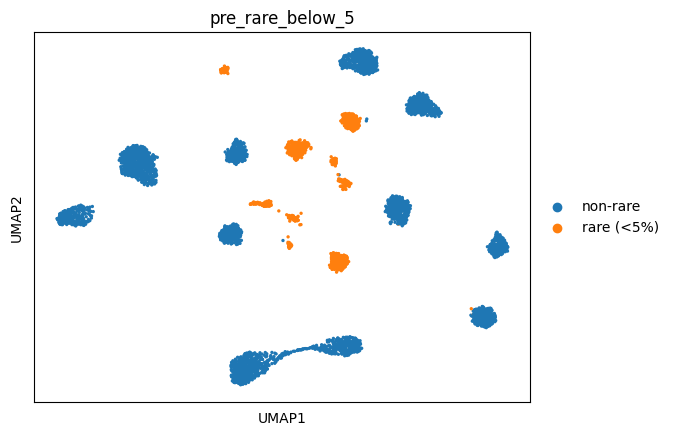

In [35]:
sc.pl.umap(adata, color=['pre_rare_below_5'], save=True)
# color=['true_rare_below_5', 'pre_rare_below_5'],

In [8]:
FiRE_results = pd.read_csv('../benchmark/results/s1d1/FiRE_rare_cells_status_fire.csv')
adata.obs['fire'] = FiRE_results['Status'].tolist()
adata.obs['fire'] 

GCATTAGCATAAGCGG-1-s1d1    non-rare
TACAGGTGTTAGAGTA-1-s1d1    non-rare
AGGATCTAGGTCTACT-1-s1d1    non-rare
GTAGAAAGTGACACAG-1-s1d1    non-rare
TCCGAAAAGGATCATA-1-s1d1    non-rare
                             ...   
GTCGAATAGTTTCGGT-1-s1d1    non-rare
AGTAGTCTCTGGGCGT-1-s1d1    non-rare
GCCCGAAGTATGGAGC-1-s1d1    non-rare
CTACATTAGCGCGTTC-1-s1d1    non-rare
GATTCTTTCACCCATC-1-s1d1    non-rare
Name: fire, Length: 5227, dtype: object

In [9]:
GapClust_results = pd.read_csv('../benchmark/results/s1d1/GapClust_rare_cells_status.csv')
adata.obs['gapclust'] = GapClust_results['Status'].tolist()

In [10]:
GiniClust3_results = pd.read_csv('../benchmark/results/s1d1/GiniClust3_rare_cells_indices.csv')
adata.obs['giniclust3'] = GiniClust3_results['rare_cells'].tolist()

In [11]:
RaceID_results = pd.read_csv('../benchmark/results/s1d1/RaceID3_rare_cells_status.csv')
adata.obs['raceid3'] = RaceID_results['Status'].tolist()

In [12]:
CellSIUS_results = pd.read_csv('../benchmark/results/s1d1/rare_cells_status_cellsius.csv')
adata.obs['cellsius'] = CellSIUS_results['Status'].tolist()

In [13]:
SCMER_results = pd.read_csv('../benchmark/results/s1d1/SCMER_rare_cells_indices.csv')
adata.obs['scmer'] = SCMER_results['rare_cells'].tolist()

In [14]:
scCAD_results = pd.read_csv('../benchmark/results/s1d1/scCAD_rare_cells_indices.csv')
adata.obs['sccad'] = scCAD_results['rare_cells'].tolist()

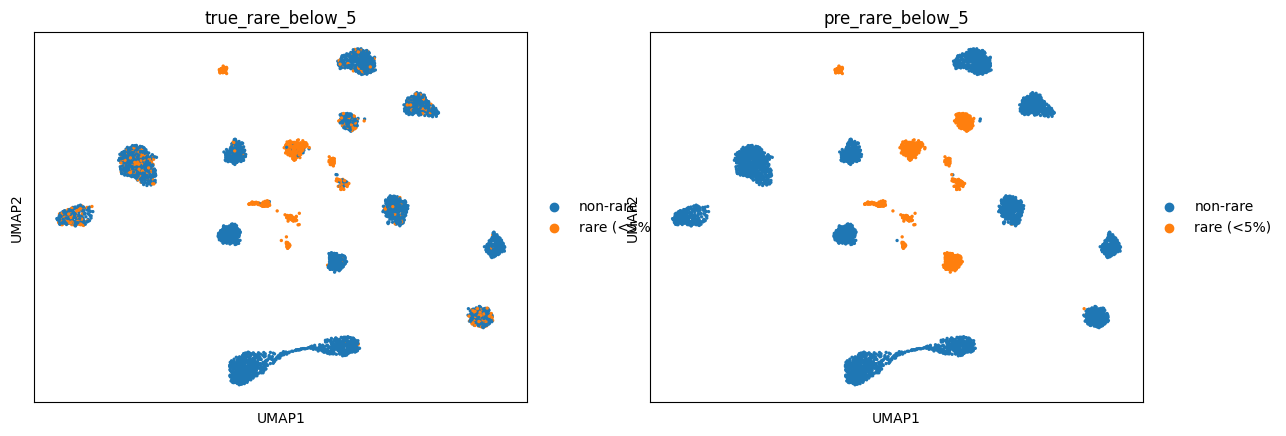

In [32]:
# 获取真实标签中小于 5% 的稀有细胞类型
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 定义小于5%的稀有细胞类型
target_cell_types_below_5 = cell_type_proportions[cell_type_proportions < 0.05].index.tolist()

# 标记真实标签中小于5%的细胞
adata.obs['true_rare_below_5'] = adata.obs['Annotation'].apply(
    lambda x: 'rare (<5%)' if x in target_cell_types_below_5 else 'non-rare'
)

# 映射 `pre` 的结果
pre_labels = adata.obs['pre']
cluster_counts = pre_labels.value_counts(normalize=True)

# 定义小于5%的稀有簇
rare_clusters_below_5 = cluster_counts[cluster_counts < 0.045].index.tolist()

# 映射到 `rare` 和 `non-rare`
adata.obs['pre_rare_below_5'] = adata.obs['pre'].apply(
    lambda x: 'rare (<5%)' if x in rare_clusters_below_5 else 'non-rare'
)

# 绘制真实标签和 `pre` 的预测结果
sc.pl.umap(adata, color=['true_rare_below_5', 'pre_rare_below_5'], show=True)


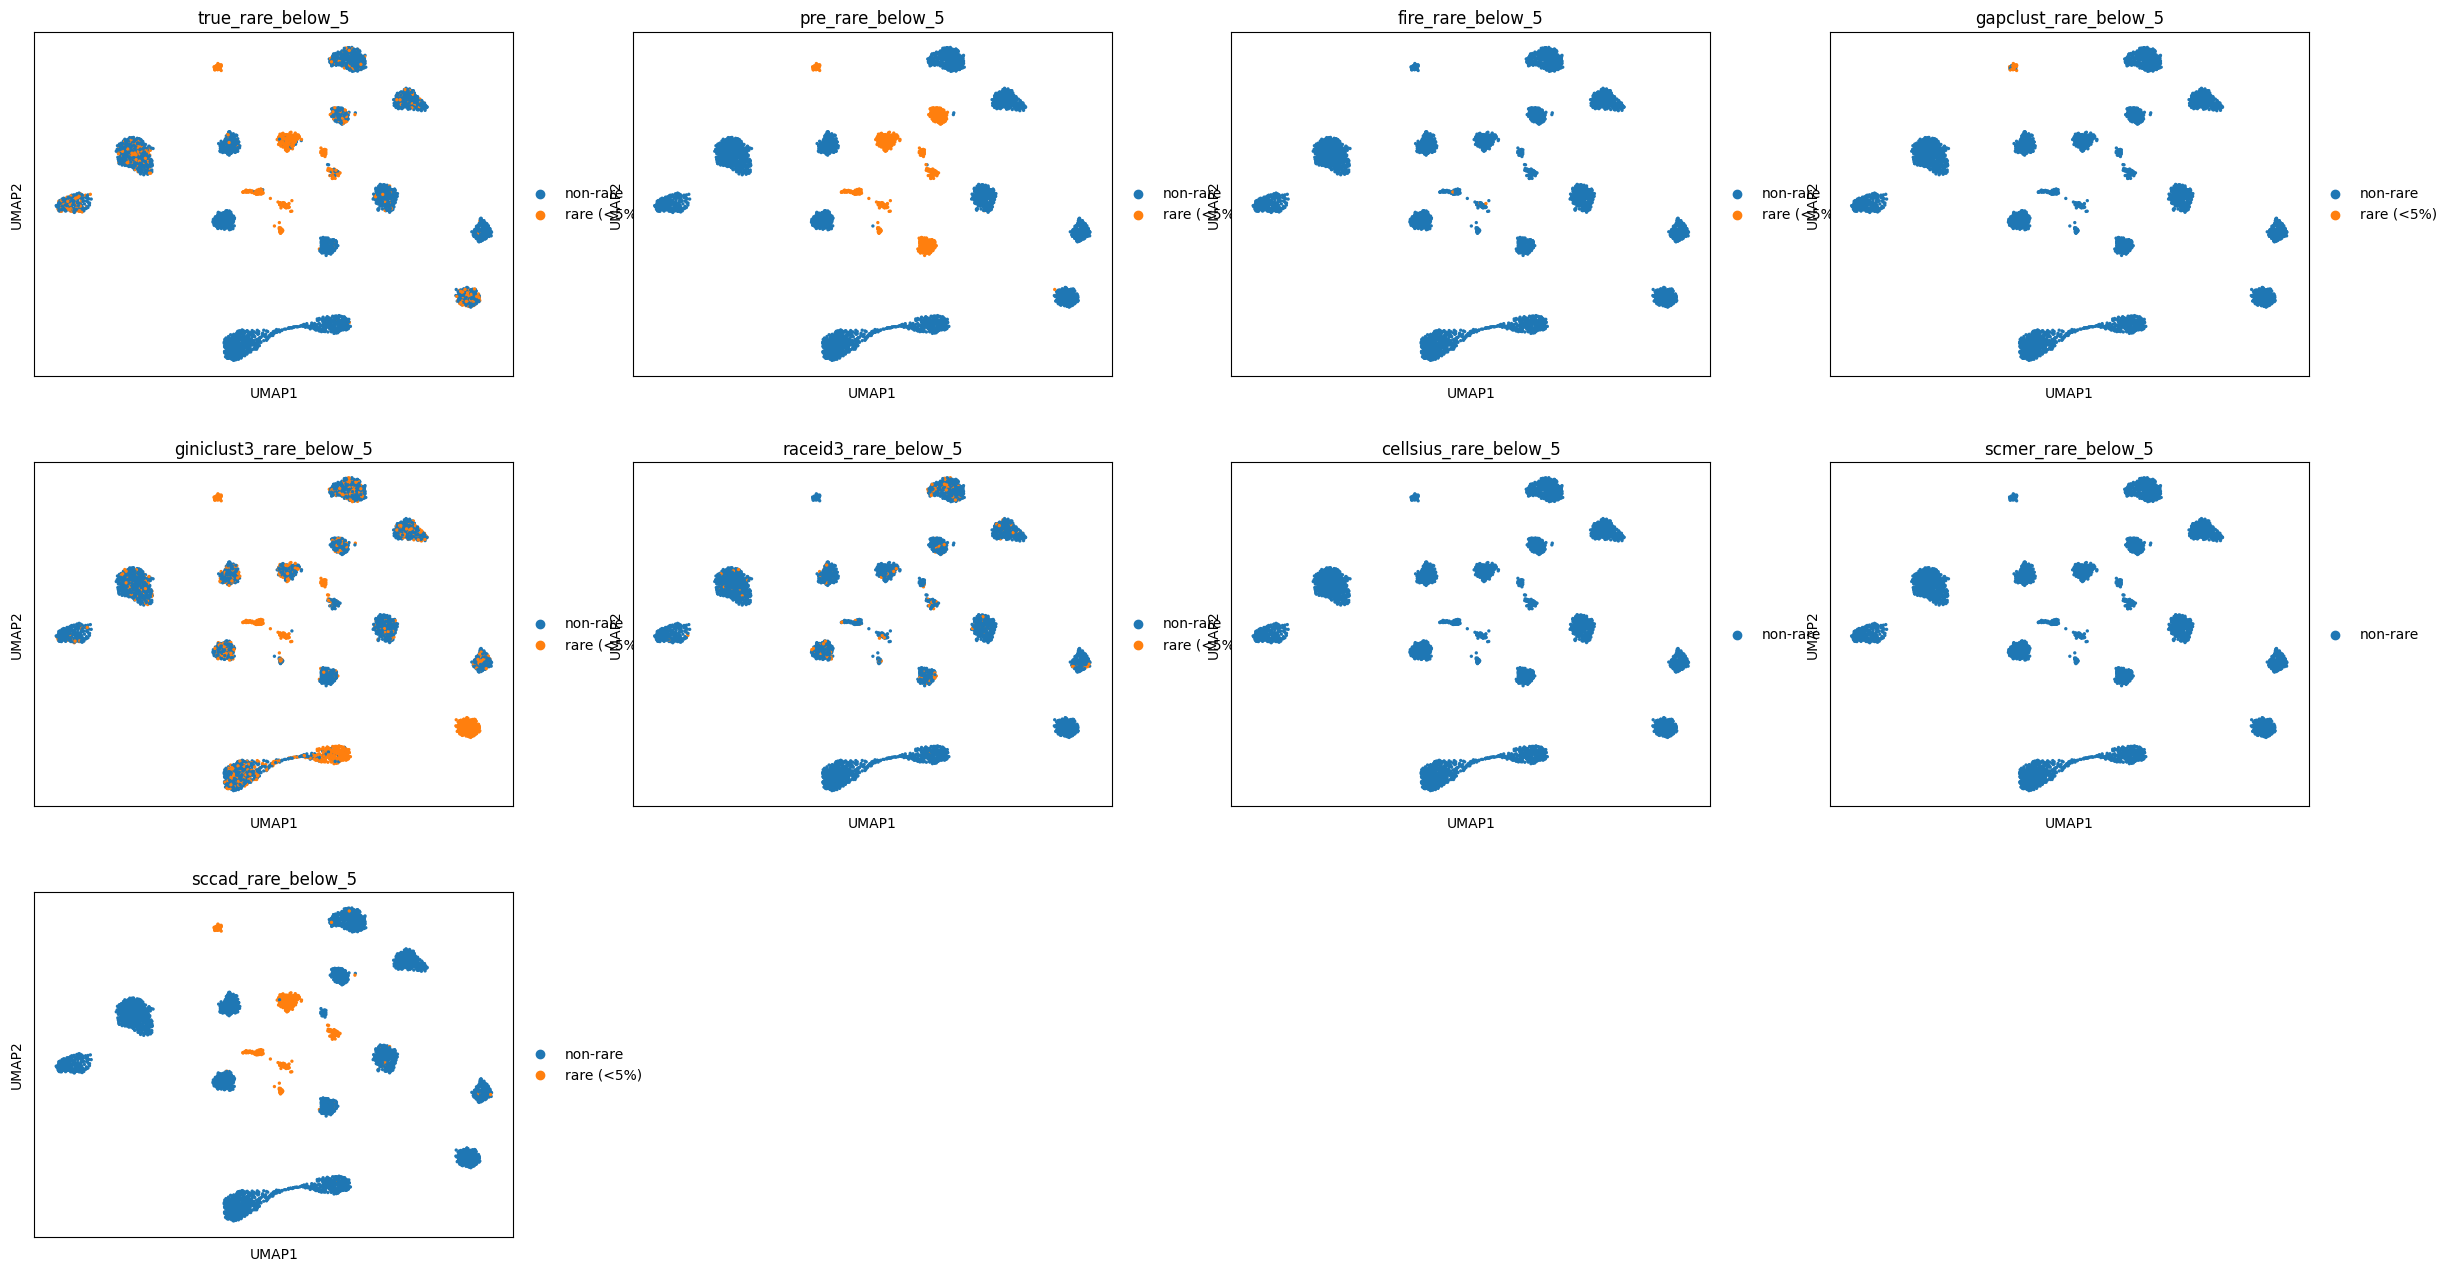

In [33]:
# 获取真实标签中小于 5% 的稀有细胞类型
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 定义小于5%的稀有细胞类型
target_cell_types_below_5 = cell_type_proportions[cell_type_proportions < 0.05].index.tolist()

# 标记真实标签中小于5%的细胞
adata.obs['true_rare_below_5'] = adata.obs['Annotation'].apply(
    lambda x: 'rare (<5%)' if x in target_cell_types_below_5 else 'non-rare'
)

# 映射 `pre` 的结果
if 'pre' in adata.obs.columns:
    pre_labels = adata.obs['pre']
    cluster_counts = pre_labels.value_counts(normalize=True)

    # 定义小于5%的稀有簇
    rare_clusters_below_5 = cluster_counts[cluster_counts < 0.045].index.tolist()

    # 映射到 `rare` 和 `non-rare`
    adata.obs['pre_rare_below_5'] = adata.obs['pre'].apply(
        lambda x: 'rare (<5%)' if x in rare_clusters_below_5 else 'non-rare'
    )
else:
    raise ValueError("'pre' 列未在 adata.obs 中找到！")

# 对比模型和 `pre` 的预测结果
models = ['fire', 'gapclust', 'giniclust3', 'raceid3', 'cellsius', 'scmer', 'sccad']

# 处理每个模型的预测结果
for model in models:
    if model not in adata.obs.columns:
        print(f"Model {model} not found in adata.obs, skipping...")
        continue

    # 映射模型的预测结果到稀有细胞类别
    adata.obs[f'{model}_rare_below_5'] = adata.obs[model].map(
        {'rare': 'rare (<5%)', 'non-rare': 'non-rare'}
    ).fillna('non-rare')  # 若存在 NaN，默认为 non-rare

# 确保绘图的列存在于 adata.obs
umap_colors = ['true_rare_below_5', 'pre_rare_below_5'] + [
    f'{model}_rare_below_5' for model in models if f'{model}_rare_below_5' in adata.obs
]

# UMAP 可视化
sc.pl.umap(adata, color=umap_colors, show=True)


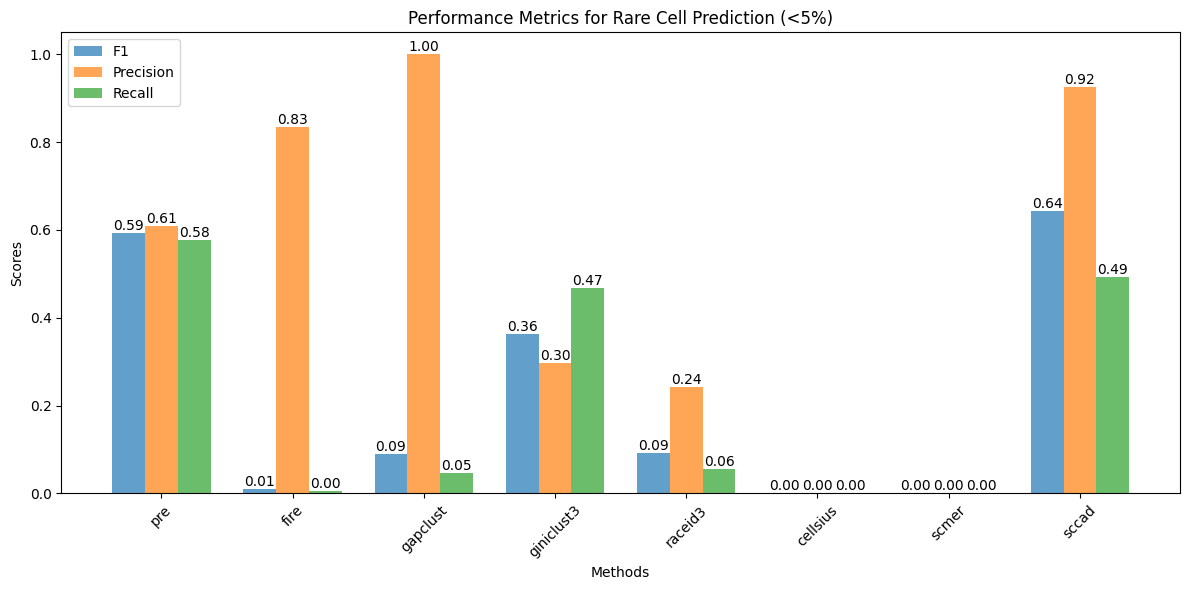

In [34]:
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

# 初始化存储结果的字典
results = {}

# 提取真实标签
true_labels = adata.obs['true_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})

# 计算 `pre` 的指标
if 'pre_rare_below_5' in adata.obs.columns:
    pre_predicted_labels = adata.obs['pre_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
    f1_pre = f1_score(true_labels, pre_predicted_labels)
    precision_pre = precision_score(true_labels, pre_predicted_labels)
    recall_pre = recall_score(true_labels, pre_predicted_labels)
    results['pre'] = {'F1': f1_pre, 'Precision': precision_pre, 'Recall': recall_pre}

# 计算其他模型的指标
models = ['fire', 'gapclust', 'giniclust3', 'raceid3', 'cellsius', 'scmer', 'sccad']
for model in models:
    if f'{model}_rare_below_5' in adata.obs.columns:
        predicted_labels = adata.obs[f'{model}_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
        f1 = f1_score(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels)
        recall = recall_score(true_labels, predicted_labels)
        results[model] = {'F1': f1, 'Precision': precision, 'Recall': recall}

# 准备数据用于绘图
methods = list(results.keys())
f1_scores = [results[method]['F1'] for method in methods]
precision_scores = [results[method]['Precision'] for method in methods]
recall_scores = [results[method]['Recall'] for method in methods]

# 绘制柱状图并显示具体数值
x = range(len(methods))
bar_width = 0.25

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, f1_scores, width=bar_width, label='F1', alpha=0.7)
bars2 = plt.bar([p + bar_width for p in x], precision_scores, width=bar_width, label='Precision', alpha=0.7)
bars3 = plt.bar([p + 2 * bar_width for p in x], recall_scores, width=bar_width, label='Recall', alpha=0.7)

# 添加数值显示
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bars3:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.xticks([p + bar_width for p in x], methods, rotation=45)
plt.xlabel('Methods')
plt.ylabel('Scores')
plt.title('Performance Metrics for Rare Cell Prediction (<5%)')
plt.legend()
plt.tight_layout()

# 保存图表并显示
plt.savefig('figures/metrics.pdf', format='pdf', bbox_inches='tight')
plt.show()
